# Budget Analysis

**How to use:**
1. Drop your bank CSV/Excel exports into `data/raw/` (they stay private — git-ignored).
2. Run all cells. If `data/raw/` is empty, it falls back to `data/sample_transactions.csv` so you can see how it works.
3. Tweak the keyword rules in `src/categorize.py` to match your own spending.

Convention: `amount` is **negative for money out**, **positive for money in**.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Make the project root importable so `src` works from the notebooks/ folder.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import load_all_raw, load_transactions, categorize

try:
    df = load_all_raw(ROOT / "data" / "raw")
    print(f"Loaded your data from data/raw/ ({len(df)} transactions).")
except FileNotFoundError:
    df = load_transactions(ROOT / "data" / "sample_transactions.csv", account="sample")
    print(f"No files in data/raw/ — using sample data ({len(df)} transactions).")

df = categorize(df)
df["month"] = df["date"].dt.to_period("M").astype(str)
df.head()

Matplotlib is building the font cache; this may take a moment.


No files in data/raw/ — using sample data (53 transactions).


,date,description,amount,account,category,month
0,2025-01-02,PAYROLL DIRECT DEPOSIT ACME CORP,3200.00,sample,Income,2025-01
1,2025-01-03,RENT PAYMENT GREENWOOD APTS,-1450.00,sample,Housing,2025-01
2,2025-01-04,WHOLE FOODS MARKET,-86.42,sample,Groceries,2025-01
3,2025-01-04,STARBUCKS STORE 1123,-5.75,sample,Dining,2025-01
4,2025-01-05,SHELL GAS STATION,-48.20,sample,Transport,2025-01


## Monthly income vs. spending

In [2]:
monthly = df.groupby("month")["amount"].agg(
    income=lambda s: s[s > 0].sum(),
    spending=lambda s: -s[s < 0].sum(),
)
monthly["net"] = monthly["income"] - monthly["spending"]
monthly.round(2)

,income,spending,net
month,,,
2025-01,3202.14,2140.92,1061.22
2025-02,3200.00,2498.82,701.18
2025-03,3202.31,2811.46,390.85


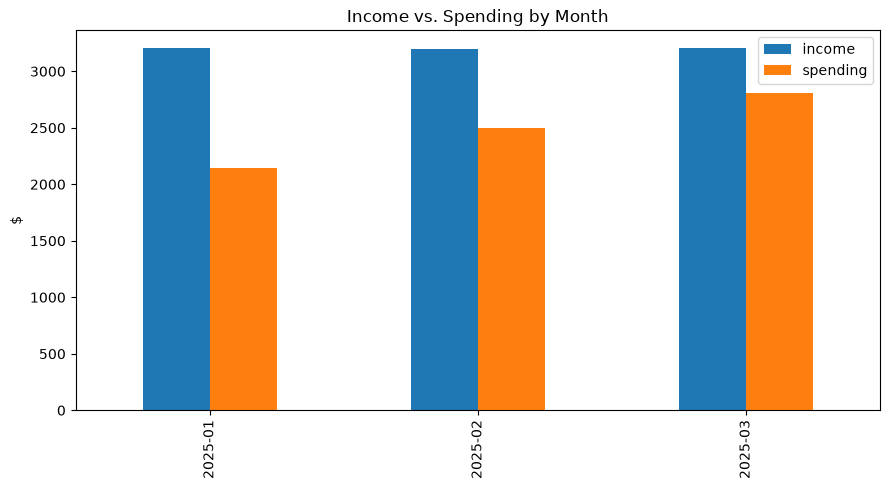

In [3]:
ax = monthly[["income", "spending"]].plot(kind="bar", figsize=(9, 5))
ax.set_title("Income vs. Spending by Month")
ax.set_ylabel("$")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Where the money goes (spending by category)

In [4]:
spend = df[df["amount"] < 0].copy()
by_cat = (-spend.groupby("category")["amount"].sum()).sort_values(ascending=False)
by_cat.round(2)

category
Housing          4350.00
Travel            730.00
Shopping          577.91
Utilities         516.22
Groceries         489.13
Health            289.15
Dining            216.35
Transport         200.00
Subscriptions      79.44
Fees                3.00
Name: amount, dtype: float64

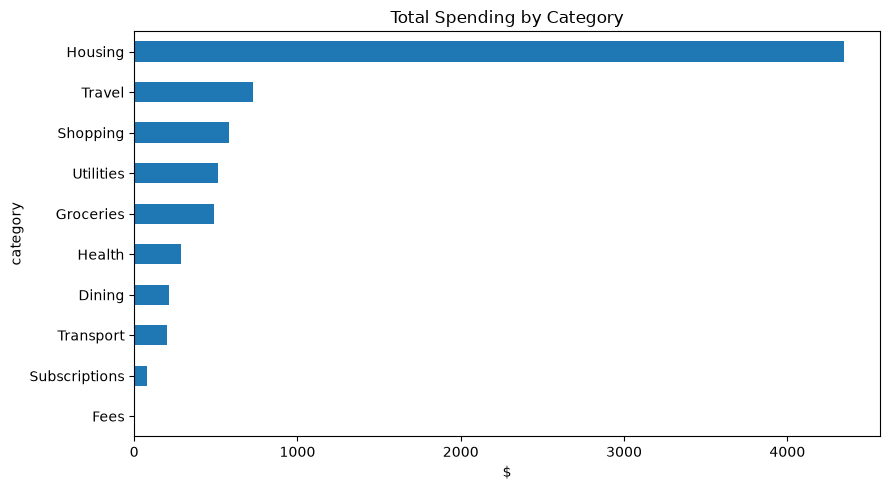

In [5]:
ax = by_cat.plot(kind="barh", figsize=(9, 5))
ax.invert_yaxis()
ax.set_title("Total Spending by Category")
ax.set_xlabel("$")
plt.tight_layout()
plt.show()

## Top merchants & anything uncategorized

Rows tagged `Uncategorized` are the ones to teach `src/categorize.py` about.

In [6]:
top = (-spend.groupby("description")["amount"].sum()).sort_values(ascending=False).head(10)
print("Top 10 spending descriptions:")
print(top.round(2).to_string())

unc = spend[spend["category"] == "Uncategorized"]
print(f"\nUncategorized spending: ${-unc['amount'].sum():.2f} across {len(unc)} transactions")

Top 10 spending descriptions:
description
RENT PAYMENT GREENWOOD APTS    4350.00
AIRBNB STAY                     420.00
DELTA AIRLINES                  310.00
ELECTRIC UTILITY CO             276.25
AMAZON MARKETPLACE              247.47
COMCAST INTERNET                239.97
BEST BUY                        219.99
COSTCO WHOLESALE                184.55
DENTAL CLINIC                   130.00
GYM FITNESS MEMBERSHIP          117.00

Uncategorized spending: $-0.00 across 0 transactions
